# Song Popularity Prediction — Exploratory Data Analysis (EDA)

**Project 3 · Music Analytics · Laura Blanco**

**Project Goal:** predict if a song will get into the **popularity top 25%** (binary classification) from it's *audio features* and metadata.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

REPORTS = Path("../reports")
REPORTS.mkdir(exist_ok=True)

AUDIO_FEATURES = [
    "danceability", "energy", "loudness", "speechiness", "acousticness",
    "instrumentalness", "liveness", "valence", "tempo", "duration_ms",
]

In [12]:
df = pd.read_csv("../data/raw/spotify_tracks.csv")
print(f"Shape: {df.shape[0]:,} songs × {df.shape[1]} columns")
df.head()

Shape: 114,000 songs × 20 columns


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 1. Data Quality

Review data types, missing values and duplicates

In [13]:
print("Data Info:")
print(df.info())

Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  str    
 1   artists           113999 non-null  str    
 2   album_name        113999 non-null  str    
 3   track_name        113999 non-null  str    
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

There are only **3 missing values**, which represents a tiny percentage of the data. These values will be removed at the cleaning process.

### 1.1 Duplicates

The Kaggle data set was built by **collecting 1.000 tracks for each genre (114 genres)**. A track could be from more than one genre simultaneously, so there is duplicated `track_id`. This is important: the **same track could get into train and test at the same time**, which would cause *data leakage*.

In [18]:
dup_id = df["track_id"].duplicated().sum()
dup_name = df.duplicated(subset=["track_name", "artists"]).sum()
print(f"track_id duplicates:             {dup_id:,}")
print(f"duplicates (track_name+artists): {dup_name:,}")
print(f"track_id unique:                 {df['track_id'].nunique():,}")

# Example of a song in multiple genres
ej = df["track_id"].value_counts().idxmax()
print("\nExample of a song in multiple genres:")
df[df["track_id"] == ej][["track_name", "artists", "track_genre", "popularity"]]

track_id duplicates:             24,259
duplicates (track_name+artists): 32,656
track_id unique:                 89,741

Example of a song in multiple genres:


,track_name,artists,track_genre,popularity
8315,Baby Blue - Remastered 2010,Badfinger,blues,67
19759,Baby Blue - Remastered 2010,Badfinger,country,67
34728,Baby Blue - Remastered 2010,Badfinger,folk,67
62226,Baby Blue - Remastered 2010,Badfinger,j-pop,67
63087,Baby Blue - Remastered 2010,Badfinger,j-rock,67
82064,Baby Blue - Remastered 2010,Badfinger,power-pop,67
84129,Baby Blue - Remastered 2010,Badfinger,psych-rock,67
99727,Baby Blue - Remastered 2010,Badfinger,singer-songwriter,67
102732,Baby Blue - Remastered 2010,Badfinger,songwriter,67


**Desing solution:** keeping one row for each `track_id` (keeping the one with the most popular genre), and the train/test split will be **by `track_id`** so there is cero *leakage*. 

### 1.2 Tracks where popularity = 0

In [ ]:
n_zero = (df["popularity"] == 0).sum()
print(f"Tracks where popularity == 0: {n_zero:,} ({n_zero / len(df):.1%})")
print("\nGenres with most popularity=0:")
print(df[df["popularity"] == 0]["track_genre"].value_counts().head(10))

Songs where popularity == 0: 16,020 (14.1%)

Genres with most popularity=0:
track_genre
jazz           681
iranian        656
romance        636
soul           611
latin          588
country        587
rock           525
dance          490
alternative    485
house          403
Name: count, dtype: int64


The **14%** of the songs have the popularity value as 0. This is not random pattern: it focuses on niche genres (classical, Iranian, romance). These tracks likely do not have enough plays for Spotify to calculate a reliable score. This will be documented as an **open decision** for feature engineering: it will be evaluated modeling with and without them.

## 2. Popularity distribution

The variable `popularity` (0–100) is the heart of the project. This is a variable that measures popularity at a sort of percentage, this variable will help to deciding if the song will be a hit or not.

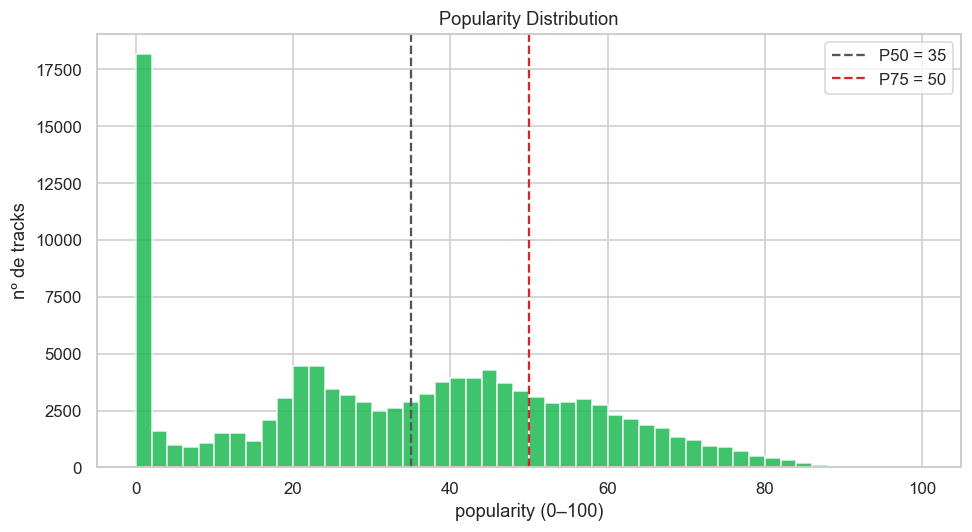

count    114000.0
mean         33.2
std          22.3
min           0.0
25%          17.0
50%          35.0
75%          50.0
max         100.0
Name: popularity, dtype: float64


In [22]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(df["popularity"], bins=50, color="#1DB954", edgecolor="white", alpha=0.85)
for q, c in [(0.5, "#555"), (0.75, "#d62728")]:
    v = df["popularity"].quantile(q)
    ax.axvline(v, color=c, ls="--", lw=1.5, label=f"P{int(q*100)} = {v:.0f}")
ax.set(title="Popularity Distribution", xlabel="popularity (0–100)", ylabel="nº de tracks")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "fig1_dist_popularity.png", bbox_inches="tight")
plt.show()

print(df["popularity"].describe().round(1))

The popularity distribution is **biased to the left**: most of tracks have low popularity. Exactly the expected behavior.

## 3. Definition of the target variable

Define the **binary classification**: a tracks is a *hit* if it is at the **top 25% of popularity** (`popularity ≥ P75`).

Threshold (P75): popularity >= 50


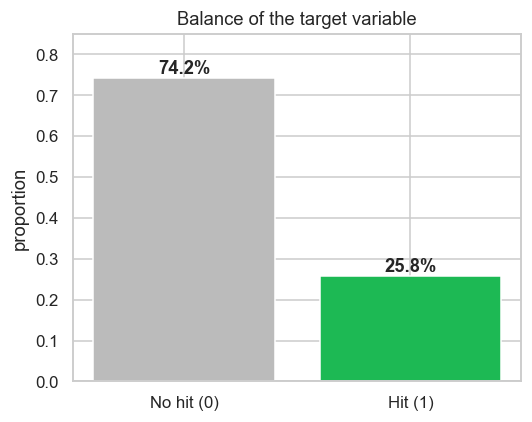

In [23]:
THRESHOLD = df["popularity"].quantile(0.75)
df["is_hit"] = (df["popularity"] >= THRESHOLD).astype(int)
print(f"Threshold (P75): popularity >= {THRESHOLD:.0f}")

balance = df["is_hit"].value_counts(normalize=True)
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["No hit (0)", "Hit (1)"], balance.values, color=["#bbb", "#1DB954"])
for i, v in enumerate(balance.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center", fontweight="bold")
ax.set(title="Balance of the target variable", ylabel="proportion", ylim=(0, 0.85))
plt.tight_layout()
plt.savefig(REPORTS / "fig2_target_balance.png", bbox_inches="tight")
plt.show()

The target sets at **~26% true / 74% false**. With a moderate and manageble imbalance (`class_weight` or/and `scale_pos_weight` will be used and the model will be evaluated by AUC-ROC and F1, no accuracy).

## 4. What features predict popularity? — Audio features

Examine lineal correlation of each audio features with popularity.

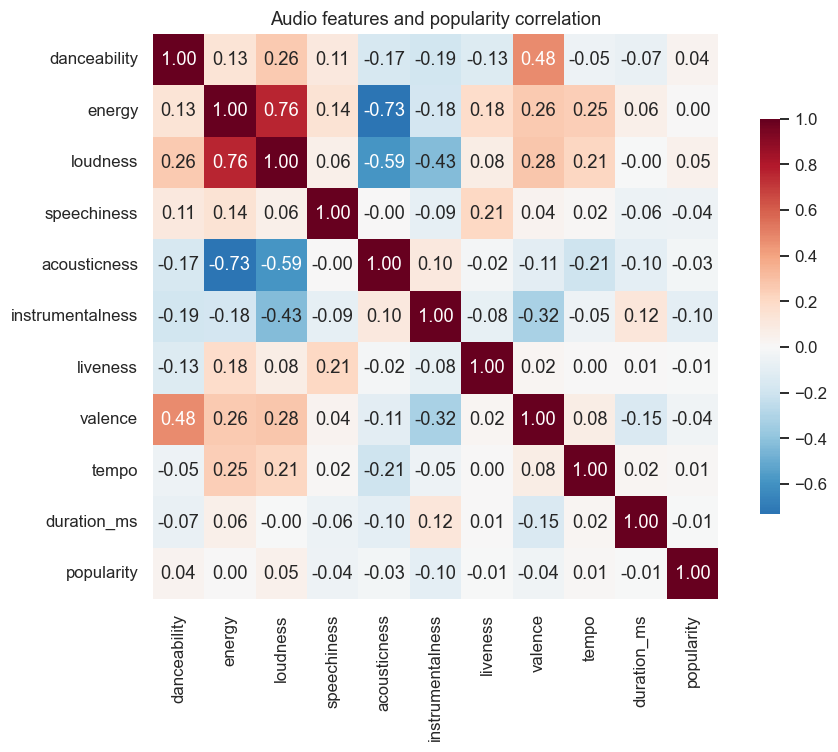

Popularity correlation (ordered):
loudness            0.050
danceability        0.035
tempo               0.013
energy              0.001
liveness           -0.005
duration_ms        -0.007
acousticness       -0.025
valence            -0.041
speechiness        -0.045
instrumentalness   -0.095
Name: popularity, dtype: float64


In [28]:
corr = df[AUDIO_FEATURES + ["popularity"]].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Audio features and popularity correlation")
plt.tight_layout()
plt.savefig(REPORTS / "fig3_corr_heatmap.png", bbox_inches="tight")
plt.show()

print("Popularity correlation (ordered):")
print(corr["popularity"].drop("popularity").sort_values(ascending=False).round(3))

### Main finding

**Audio features themselves do not have a strong linal correlation with popularity** (each one with |r| < 0.1). This leads to three conclusions:

1. 'How the track sounds?' is not enough to predict a *hit*. The context and qualitative variables (genre, artist) are more important.
2. It's necessary to include and transform **genre** into a feature and to enrich **the relative popularity of an artist** (Last.fm).
3. It already indicates that a lineal model will not do a good job and that it will be better to work with no linear models (such as Random Forest or LightGBM) that can capture more variable interactions.

Most relevant feature distribution between *hits* and *no hits*:

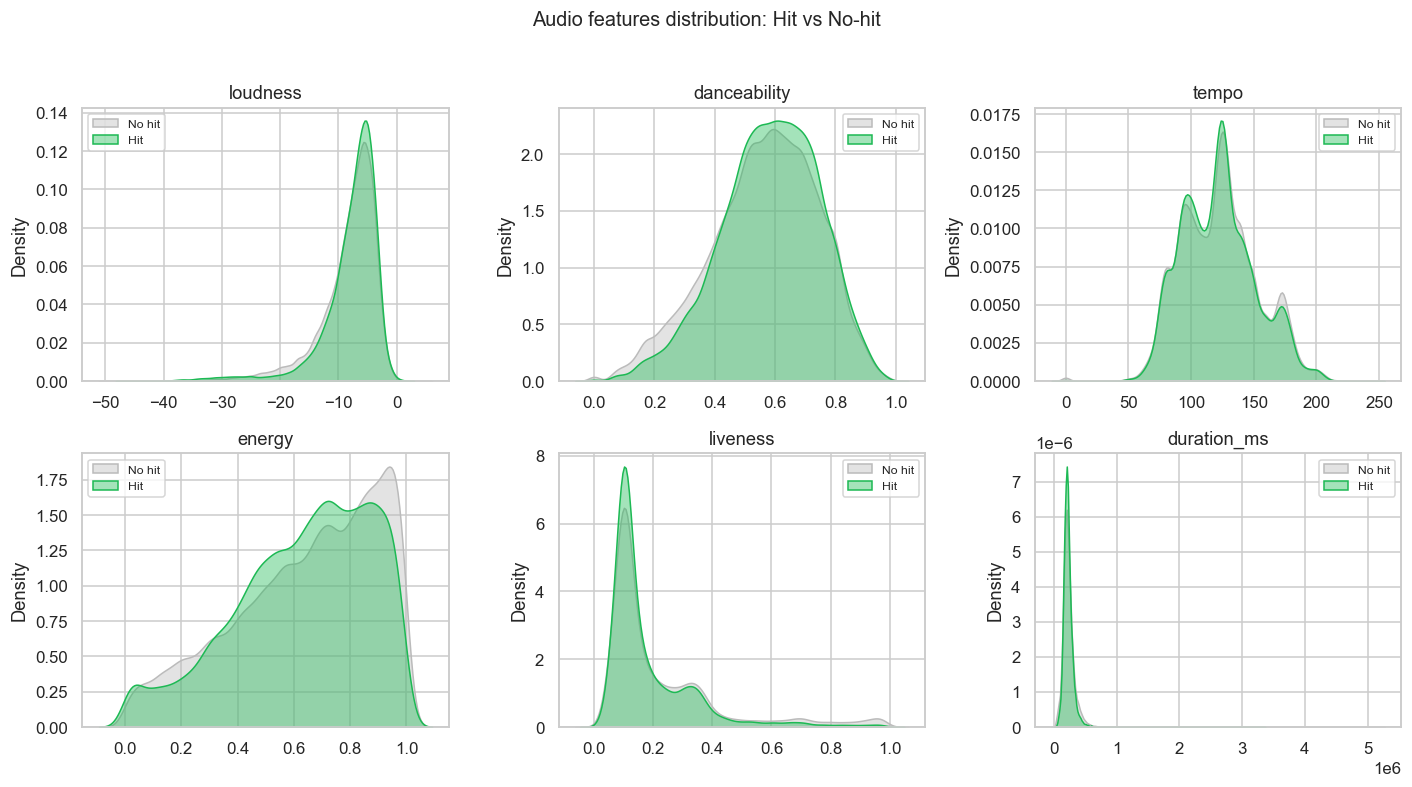

In [30]:
key_feats = corr["popularity"].drop("popularity").sort_values(ascending=False).head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, feat in zip(axes.ravel(), key_feats):
    for hit, color, label in [(0, "#bbb", "No hit"), (1, "#1DB954", "Hit")]:
        sns.kdeplot(df[df["is_hit"] == hit][feat], ax=ax, color=color,
                    fill=True, alpha=0.4, label=label, warn_singular=False)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
fig.suptitle("Audio features distribution: Hit vs No-hit", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS / "fig4_features_by_target.png", bbox_inches="tight")
plt.show()

The distributions of hits and non-hits **overlap significantly** across almost all features—visual confirmation that the individual signal is weak. Subtle differences, like hits tend to be somewhat more *danceable*, but not overly energetic, which will be exploited by nonlinear models through interactions.

## 5. Genre analysis

This is one of the strongest signal of correlation: average popularity varies **dramatically** between genres.

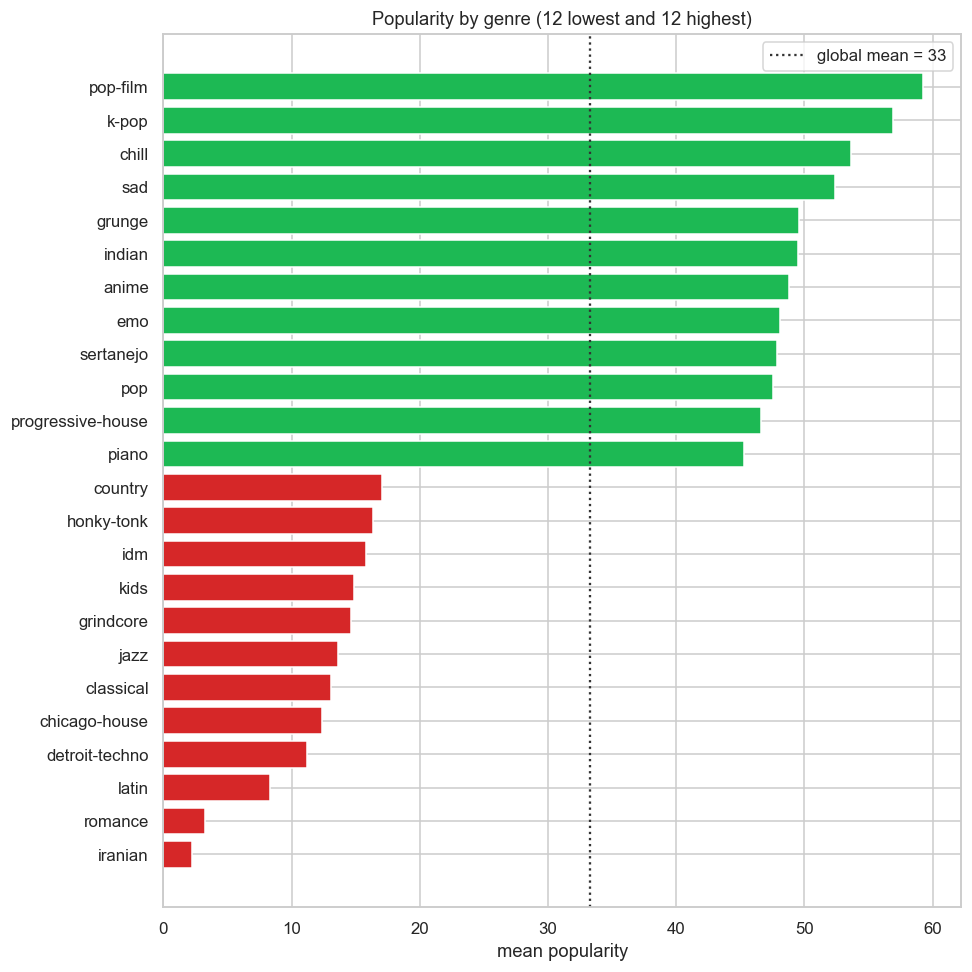

In [31]:
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values()
top_bottom = pd.concat([genre_pop.head(12), genre_pop.tail(12)])

fig, ax = plt.subplots(figsize=(9, 9))
colors = ["#d62728"] * 12 + ["#1DB954"] * 12
ax.barh(top_bottom.index, top_bottom.values, color=colors)
ax.set(title="Popularity by genre (12 lowest and 12 highest)",
       xlabel="mean popularity")
ax.axvline(df["popularity"].mean(), color="#333", ls=":", label=f"global mean = {df['popularity'].mean():.0f}")
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / "fig5_popularity_by_genre.png", bbox_inches="tight")
plt.show()

The gap is enormous: from **~3** (Iranian, Romance, Latin) to **~59** (film pop, K-pop). Genre is by far the most predictive feature.

**Implications for model bias:** since baseline popularity varies so much by genre, a model trained on the entire catalog will tend to predict “hit” for globally popular genres and “non-hit” for niche ones-regardless of the song’s quality. In the evaluation phase, this will explicitly measure performance **by genre** (does it predict better for pop than for reggaeton/Latin?), which is the **differentiator** of the project.

## 6. EDA conclusions

**Findings:**
- Clean dataset (~114k songs, 114 genres), with duplicates by `track_id` requiring deduplication + splitting by ID to avoid leakage.
- ~14% of songs with popularity=0 (niche); inclusion decision pending.
- Well-defined and balanced *top 25%* target (~26% positives).
- **Individual audio features have almost zero linear predictive power.**
- **Genre is the dominant signal** and the primary source of bias to be analyzed.

---
*Continued in  `02_feature_engineering.ipynb`*